In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

print("Libraries loaded ✓")

Libraries loaded ✓


In [56]:
pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [57]:
# Load the utilities data
df = pd.read_excel("Utilities.xlsx", sheet_name="Usage")

# Quick first look
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (38, 26)

Columns:
['Year', 'Month', 'Gas Use', 'Elec Use', 'Solar Production', 'Elec Import', 'Elec Export', 'EV Charger', 'Net Use', 'Net Use (-EV)', 'Heating Degree Days', 'Gas Cost', 'Elec Import Cost', 'Export Income', 'Feedback Costs', 'Net Elec Cost', 'Fixed Costs', 'EV Charger.1', 'Net House Elec Cost', 'Net House Cost (Gas & Elec)', 'Overall Cost', 'Remarks', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25']

First 5 rows:


,Year,Month,Gas Use,Elec Use,Solar Production,Elec Import,Elec Export,EV Charger,Net Use,Net Use (-EV),...,Fixed Costs,EV Charger.1,Net House Elec Cost,Net House Cost (Gas & Elec),Overall Cost,Remarks,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,2023,Jan,0,0,0,0,0,0.0,0,0.0,...,0.00,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
1,2023,Feb,0,0,0,0,0,0.0,0,0.0,...,0.00,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
2,2023,Mar,0,0,0,0,0,0.0,0,0.0,...,0.00,0.0,0.00,0.00,0.00,NaN,NaN,NaN,NaN,NaN
3,2023,Apr,0,0,0,0,0,0.0,0,0.0,...,0.00,0.0,0.00,0.00,0.00,NaN,Elec Tariff,EV Tariff,Profit,Gas Tariff
4,2023,May,7,10,26,55,-73,0.0,-18,-18.0,...,4.79,0.0,-7.12,7.24,7.24,NaN,0.390182,0,0,1.367143


In [58]:
# Investigate the unnamed columns
print("Unnamed columns content:")
print(df[["Unnamed: 22", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25"]].dropna().head(10))

print(f"\nYear column type: {df['Year'].dtype}")
print(f"Year unique values: {df['Year'].unique()}")

print(f"\nRows with all zero energy values:")
zero_rows = df[df["Solar Production"] == 0]
print(f"Count: {len(zero_rows)}")
print(zero_rows[["Year", "Month", "Solar Production", "Gas Use", "Elec Use"]])

Unnamed columns content:
    Unnamed: 22 Unnamed: 23 Unnamed: 24 Unnamed: 25
3   Elec Tariff   EV Tariff      Profit  Gas Tariff
4      0.390182           0           0    1.367143
5      0.389242           0           0    1.366538
6      0.388779           0           0    1.366389
7      0.389701           0           0    1.366552
8      0.391538    0.249131    5.733338    1.366667
9      0.387674    0.345934     4.73717    1.366508
10     0.388465    0.357833    4.472056    1.366484
11     0.387119    0.377245    2.698881    1.366509
12     0.368082    0.371606   -0.769745    1.479291

Year column type: object
Year unique values: [2023 2024 2025 2026 'Total']

Rows with all zero energy values:
Count: 4
   Year Month  Solar Production  Gas Use  Elec Use
0  2023   Jan                 0        0         0
1  2023   Feb                 0        0         0
2  2023   Mar                 0        0         0
3  2023   Apr                 0        0         0


In [59]:
print(f"Shape: {df.shape}")

Shape: (38, 26)


In [60]:
print(f"Shape: {zero_rows.shape}")

Shape: (4, 26)


In [61]:
# ------ DATA CLEANING -----------------------------------------------

# Keep the raw data untouched
raw_df = df.copy()

# Work on a clean copy

# Step 1 - Remove rows where Year is 'Total' or energy data is all zero
df = df[df["Year"] != "Total"]
df = df[df["Solar Production"] != 0]

# Step 2 - Convert Year to Integer
df["Year"] = df["Year"].astype(int)

# Step 3 - Rename unnamed tariff columns
df = df.rename(columns={
    "Unnamed: 22": "Elec Tariff",
    "Unnamed: 23": "EV Tariff",
    "Unnamed: 24": "EV Profit",
    "Unnamed: 25": "Gas Tariff"
})

# Step 4 - Reset the index so it starts from 0
df = df.reset_index(drop=True)

# Confirm results
print(f"Shape after cleaning: {df.shape}")
print(f"Year range: {df['Year'].min()} to {df['Year'].max()}")
print(f"Months: {len(df)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape after cleaning: (33, 26)
Year range: 2023 to 2026
Months: 33

First 3 rows:


,Year,Month,Gas Use,Elec Use,Solar Production,Elec Import,Elec Export,EV Charger,Net Use,Net Use (-EV),...,Fixed Costs,EV Charger.1,Net House Elec Cost,Net House Cost (Gas & Elec),Overall Cost,Remarks,Elec Tariff,EV Tariff,EV Profit,Gas Tariff
0,2023,May,7,10,26,55,-73,0.0,-18,-18.0,...,4.79,0.0,-7.12,7.24,7.24,NaN,0.390182,0,0,1.367143
1,2023,Jun,26,186,192,132,-136,0.0,-4,-4.0,...,9.59,0.0,-2.26,42.86,42.86,NaN,0.389242,0,0,1.366538
2,2023,Jul,36,241,162,172,-97,0.0,75,75.0,...,9.91,0.0,28.60,87.70,87.70,NaN,0.388779,0,0,1.366389


In [62]:
# Create a proper datetime column from Year and Month
df["Date"] = pd.to_datetime(df["Year"].astype(str) + " " + df["Month"], format="%Y %b")

# Set it as the index - makes time series operations much easier
df = df.set_index("Date")

print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nFirst 3 rows with new date index:")
df.head(3)

Date range: 2023-05-01 00:00:00 to 2026-01-01 00:00:00

First 3 rows with new date index:


,Year,Month,Gas Use,Elec Use,Solar Production,Elec Import,Elec Export,EV Charger,Net Use,Net Use (-EV),...,Fixed Costs,EV Charger.1,Net House Elec Cost,Net House Cost (Gas & Elec),Overall Cost,Remarks,Elec Tariff,EV Tariff,EV Profit,Gas Tariff
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-01,2023,May,7,10,26,55,-73,0.0,-18,-18.0,...,4.79,0.0,-7.12,7.24,7.24,NaN,0.390182,0,0,1.367143
2023-06-01,2023,Jun,26,186,192,132,-136,0.0,-4,-4.0,...,9.59,0.0,-2.26,42.86,42.86,NaN,0.389242,0,0,1.366538
2023-07-01,2023,Jul,36,241,162,172,-97,0.0,75,75.0,...,9.91,0.0,28.60,87.70,87.70,NaN,0.388779,0,0,1.366389


In [63]:
# Drop redundant columns now that we have a proper date index
df = df.drop(columns=["Year", "Month"])

# Also check what our data looks like now
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Shape: (33, 24)
Columns: ['Gas Use', 'Elec Use', 'Solar Production', 'Elec Import', 'Elec Export', 'EV Charger', 'Net Use', 'Net Use (-EV)', 'Heating Degree Days', 'Gas Cost', 'Elec Import Cost', 'Export Income', 'Feedback Costs', 'Net Elec Cost', 'Fixed Costs', 'EV Charger.1', 'Net House Elec Cost', 'Net House Cost (Gas & Elec)', 'Overall Cost', 'Remarks', 'Elec Tariff', 'EV Tariff', 'EV Profit', 'Gas Tariff']


,Gas Use,Elec Use,Solar Production,Elec Import,Elec Export,EV Charger,Net Use,Net Use (-EV),Heating Degree Days,Gas Cost,...,Fixed Costs,EV Charger.1,Net House Elec Cost,Net House Cost (Gas & Elec),Overall Cost,Remarks,Elec Tariff,EV Tariff,EV Profit,Gas Tariff
Date,,,,,,,,,,,,,,,,,,,,,
2023-05-01,7,10,26,55,-73,0.0,-18,-18.0,132.67,9.57,...,4.79,0.0,-7.12,7.24,7.24,NaN,0.390182,0,0,1.367143
2023-06-01,26,186,192,132,-136,0.0,-4,-4.0,16.93,35.53,...,9.59,0.0,-2.26,42.86,42.86,NaN,0.389242,0,0,1.366538
2023-07-01,36,241,162,172,-97,0.0,75,75.0,5.49,49.19,...,9.91,0.0,28.60,87.70,87.70,NaN,0.388779,0,0,1.366389


In [64]:
# Data quality check
print("── Missing Values ──────────────────────")
print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"\n── Data Types ──────────────────────────")
print(df.dtypes)

print(f"\n── Statistical Summary ─────────────────")
df.describe()

── Missing Values ──────────────────────
Heating Degree Days    13
Remarks                24
dtype: int64

── Data Types ──────────────────────────
Gas Use                          int64
Elec Use                         int64
Solar Production                 int64
Elec Import                      int64
Elec Export                      int64
EV Charger                     float64
Net Use                          int64
Net Use (-EV)                  float64
Heating Degree Days            float64
Gas Cost                       float64
Elec Import Cost               float64
Export Income                  float64
Feedback Costs                 float64
Net Elec Cost                  float64
Fixed Costs                    float64
EV Charger.1                   float64
Net House Elec Cost            float64
Net House Cost (Gas & Elec)    float64
Overall Cost                   float64
Remarks                            str
Elec Tariff                     object
EV Tariff                       o

,Gas Use,Elec Use,Solar Production,Elec Import,Elec Export,EV Charger,Net Use,Net Use (-EV),Heating Degree Days,Gas Cost,Elec Import Cost,Export Income,Feedback Costs,Net Elec Cost,Fixed Costs,EV Charger.1,Net House Elec Cost,Net House Cost (Gas & Elec),Overall Cost
count,33.000000,33.000000,33.000000,33.00000,33.000000,33.000000,33.000000,33.000000,20.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,106.212121,473.818182,115.000000,427.69697,-66.060606,-163.517576,361.636364,198.118788,162.601000,147.276667,129.734545,-19.619394,4.255758,114.370909,18.889394,-59.975455,54.395455,220.561515,280.536970
std,116.191049,270.722119,66.710663,272.92003,44.225939,133.706100,300.758501,212.330236,147.488743,162.671596,79.633737,13.166697,6.228772,88.509946,7.029276,52.493853,57.845140,180.332485,199.399302
min,2.000000,10.000000,17.000000,55.00000,-156.000000,-453.580000,-18.000000,-18.000000,0.000000,2.610000,21.460000,-53.640000,0.000000,-7.120000,4.790000,-175.060000,-21.240000,7.240000,7.240000
25%,22.000000,316.000000,46.000000,286.00000,-97.000000,-273.350000,193.000000,66.380000,17.432500,27.470000,66.870000,-28.580000,0.000000,55.450000,13.570000,-103.120000,13.000000,81.160000,122.140000
50%,39.000000,437.000000,122.000000,404.00000,-73.000000,-145.990000,308.000000,132.540000,134.575000,55.640000,109.440000,-19.980000,0.460000,96.420000,19.440000,-52.240000,38.380000,171.140000,256.480000
75%,199.000000,550.000000,175.000000,485.00000,-20.000000,-67.330000,438.000000,243.660000,293.497500,279.560000,154.040000,-7.660000,6.160000,149.020000,25.810000,-20.840000,78.790000,313.760000,411.710000
max,395.000000,1351.000000,215.000000,1313.00000,-3.000000,0.000000,1310.000000,856.420000,441.220000,584.320000,382.830000,-0.860000,19.340000,382.430000,28.980000,6.050000,207.370000,684.580000,765.750000


In [65]:
# Find the month with maximum solar production
max_solar_idx = df["Solar Production"].idxmax()
print(f"Max solar production: {df.loc[max_solar_idx, 'Solar Production']} kWh")
print(f"Month: {max_solar_idx.strftime('%B %Y')}")

Max solar production: 215 kWh
Month: April 2025


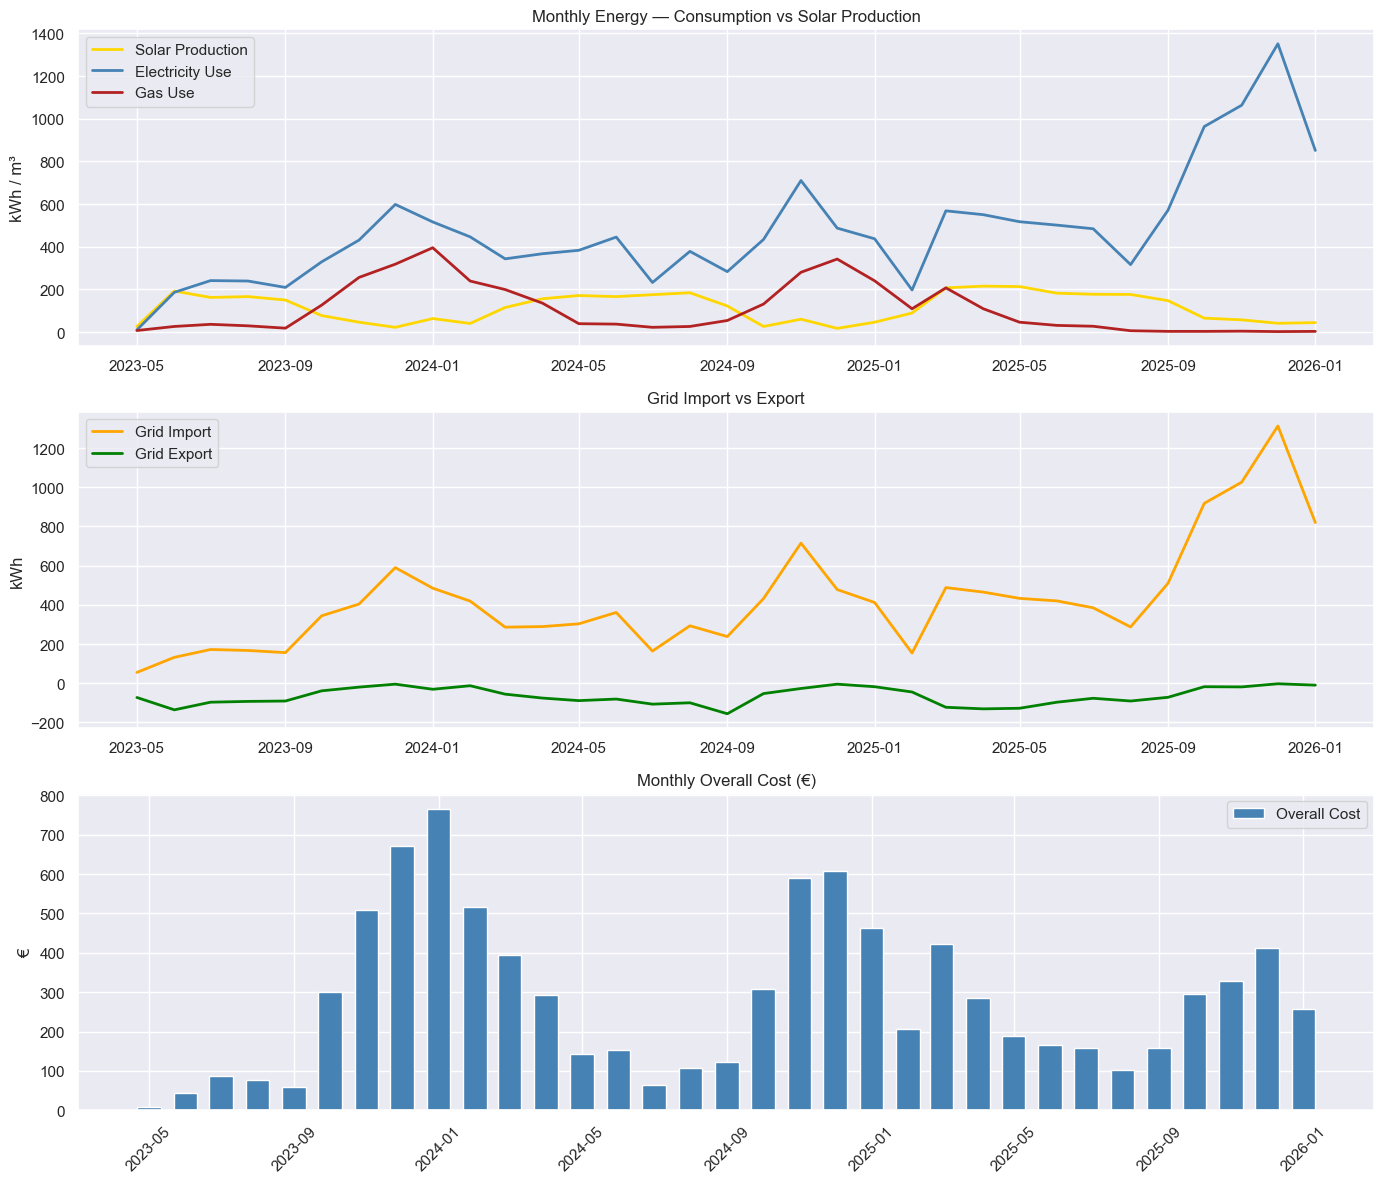

In [66]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Top - Energy consumption and solar production
axes[0].plot(df.index, df["Solar Production"], color="gold", linewidth=2, label="Solar Production")
axes[0].plot(df.index, df["Elec Use"], color="steelblue", linewidth=2, label="Electricity Use")
axes[0].plot(df.index, df["Gas Use"], color="firebrick", linewidth=2, label="Gas Use")
axes[0].set_title("Monthly Energy — Consumption vs Solar Production")
axes[0].set_ylabel("kWh / m³")
axes[0].legend()

# Middle - Grid import and export
axes[1].plot(df.index, df["Elec Import"], color="orange", linewidth=2, label="Grid Import")
axes[1].plot(df.index, df["Elec Export"], color="green", linewidth=2, label="Grid Export")
axes[1].set_title("Grid Import vs Export")
axes[1].set_ylabel("kWh")
axes[1].legend()

# Bottom - Monthly costs
axes[2].bar(df.index, df["Overall Cost"], width=20, color="steelblue", label="Overall Cost")
axes[2].axhline(y=0, color="black", linewidth=0.8)
axes[2].set_title("Monthly Overall Cost (€)")
axes[2].set_ylabel("€")
axes[2].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [67]:
# Rename columns to meaningful names
df = df.rename(columns={
    "Net Use": "Net Grid Use",
    "Net Use (-EV)": "Household Use"
})

# Convert gas to kWh
df["Gas kWh"] = df["Gas Use"] * 9.77

# Calculate household electricity excluding EV
df["Household Elec"] = df["Elec Use"] - df["EV Charger"].abs()

# Verify our calculations
print(df[["Solar Production", "Elec Import", "Elec Export", 
          "Elec Use", "EV Charger", "Household Elec", 
          "Gas Use", "Gas kWh"]].head(10).to_string())

            Solar Production  Elec Import  Elec Export  Elec Use  EV Charger  Household Elec  Gas Use  Gas kWh
Date                                                                                                          
2023-05-01                26           55          -73        10        0.00           10.00        7    68.39
2023-06-01               192          132         -136       186        0.00          186.00       26   254.02
2023-07-01               162          172          -97       241        0.00          241.00       36   351.72
2023-08-01               166          167          -93       239        0.00          239.00       29   283.33
2023-09-01               150          156          -91       209      -40.26          168.74       18   175.86
2023-10-01                77          344          -39       329     -113.49          215.51      126  1231.02
2023-11-01                46          404          -20       431     -145.99          285.01      256  2501.12
2

In [69]:
# Check the Elec Tariff column
print(df[["Elec Tariff", "EV Profit", "Gas Tariff"]].to_string())
print(df.columns.tolist())

           Elec Tariff  EV Profit Gas Tariff
Date                                        
2023-05-01    0.390182          0   1.367143
2023-06-01    0.389242          0   1.366538
2023-07-01    0.388779          0   1.366389
2023-08-01    0.389701          0   1.366552
2023-09-01    0.391538   5.733338   1.366667
2023-10-01    0.387674    4.73717   1.366508
2023-11-01    0.388465   4.472056   1.366484
2023-12-01    0.387119   2.698881   1.366509
2024-01-01    0.368082  -0.769745   1.479291
2024-02-01    0.367637   2.787664   1.479289
2024-03-01     0.36965   4.896364   1.479296
2024-04-01    0.370519   3.731961   1.479259
2024-05-01    0.331485  -1.015933   1.426667
2024-06-01    0.296177 -13.270071   1.351081
2024-07-01    0.265183   0.669746   1.248636
2024-08-01    0.226143  -15.88573   1.248846
2024-09-01    0.228403  -6.335324   1.248704
2024-10-01    0.286134 -18.219953   1.327023
2024-11-01    0.287049  -41.94361   1.327071
2024-12-01    0.285753 -12.512217   1.327047
2025-01-01

In [70]:
print(df[["EV Charger", "EV Charger.1", "Elec Tariff", "EV Tariff", "EV Profit", "Gas Tariff"]].head(10).to_string())

            EV Charger  EV Charger.1 Elec Tariff EV Tariff EV Profit Gas Tariff
Date                                                                           
2023-05-01        0.00          0.00    0.390182         0         0   1.367143
2023-06-01        0.00          0.00    0.389242         0         0   1.366538
2023-07-01        0.00          0.00    0.388779         0         0   1.366389
2023-08-01        0.00          0.00    0.389701         0         0   1.366552
2023-09-01      -40.26        -10.03    0.391538  0.249131  5.733338   1.366667
2023-10-01     -113.49        -39.26    0.387674  0.345934   4.73717   1.366508
2023-11-01     -145.99        -52.24    0.388465  0.357833  4.472056   1.366484
2023-12-01     -273.35       -103.12    0.387119  0.377245  2.698881   1.366509
2024-01-01     -218.43        -81.17    0.368082  0.371606 -0.769745   1.479291
2024-02-01     -103.03        -35.09    0.367637   0.34058  2.787664   1.479289


In [71]:
print(df[["EV Charger", "EV Charger.1", "Elec Tariff", "EV Tariff", "EV Profit", "Gas Tariff"]].head(10).to_string())

            EV Charger  EV Charger.1 Elec Tariff EV Tariff EV Profit Gas Tariff
Date                                                                           
2023-05-01        0.00          0.00    0.390182         0         0   1.367143
2023-06-01        0.00          0.00    0.389242         0         0   1.366538
2023-07-01        0.00          0.00    0.388779         0         0   1.366389
2023-08-01        0.00          0.00    0.389701         0         0   1.366552
2023-09-01      -40.26        -10.03    0.391538  0.249131  5.733338   1.366667
2023-10-01     -113.49        -39.26    0.387674  0.345934   4.73717   1.366508
2023-11-01     -145.99        -52.24    0.388465  0.357833  4.472056   1.366484
2023-12-01     -273.35       -103.12    0.387119  0.377245  2.698881   1.366509
2024-01-01     -218.43        -81.17    0.368082  0.371606 -0.769745   1.479291
2024-02-01     -103.03        -35.09    0.367637   0.34058  2.787664   1.479289


In [75]:
# EV Net Profit = income received - electricity cost
# Note: assumes 100% grid charging, slightly underestimates true profit
df["EV Net Profit"] = df["EV Charger.1"].abs() - (df["EV Charger"].abs() * df["Elec Tariff"])
print(df[["EV Charger", "EV Charger.1", "Elec Tariff", "EV Net Profit"]].to_string())

            EV Charger  EV Charger.1 Elec Tariff EV Net Profit
Date                                                          
2023-05-01        0.00          0.00    0.390182           0.0
2023-06-01        0.00          0.00    0.389242           0.0
2023-07-01        0.00          0.00    0.388779           0.0
2023-08-01        0.00          0.00    0.389701           0.0
2023-09-01      -40.26        -10.03    0.391538     -5.733338
2023-10-01     -113.49        -39.26    0.387674      -4.73717
2023-11-01     -145.99        -52.24    0.388465     -4.472056
2023-12-01     -273.35       -103.12    0.387119     -2.698881
2024-01-01     -218.43        -81.17    0.368082      0.769745
2024-02-01     -103.03        -35.09    0.367637     -2.787664
2024-03-01      -39.00         -9.52     0.36965     -4.896364
2024-04-01      -80.46        -26.08    0.370519     -3.731961
2024-05-01     -104.21        -35.56    0.331485      1.015933
2024-06-01     -187.32        -68.75    0.296177     13

In [76]:
print(df.index)

DatetimeIndex(['2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01',
               '2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
               '2026-01-01'],
              dtype='datetime64[us]', name='Date', freq=None)


In [77]:
# We can access year and month directly from the datetime index
print(df.index.year)   # extracts year from each date
print(df.index.month)  # extracts month number from each date

Index([2023, 2023, 2023, 2023, 2023, 2023, 2023, 2023, 2024, 2024, 2024, 2024,
       2024, 2024, 2024, 2024, 2024, 2024, 2024, 2024, 2025, 2025, 2025, 2025,
       2025, 2025, 2025, 2025, 2025, 2025, 2025, 2025, 2026],
      dtype='int32', name='Date')
Index([ 5,  6,  7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12,  1],
      dtype='int32', name='Date')


In [78]:
# Create energy year label (July to June)
def energy_year(date):
    if date.month >= 7:
        return f"EY{date.year + 1}"
    else:
        return f"EY{date.year}"

df["Energy Year"] = df.index.map(energy_year)
print(df[["Energy Year"]].to_string())

           Energy Year
Date                  
2023-05-01      EY2023
2023-06-01      EY2023
2023-07-01      EY2024
2023-08-01      EY2024
2023-09-01      EY2024
2023-10-01      EY2024
2023-11-01      EY2024
2023-12-01      EY2024
2024-01-01      EY2024
2024-02-01      EY2024
2024-03-01      EY2024
2024-04-01      EY2024
2024-05-01      EY2024
2024-06-01      EY2024
2024-07-01      EY2025
2024-08-01      EY2025
2024-09-01      EY2025
2024-10-01      EY2025
2024-11-01      EY2025
2024-12-01      EY2025
2025-01-01      EY2025
2025-02-01      EY2025
2025-03-01      EY2025
2025-04-01      EY2025
2025-05-01      EY2025
2025-06-01      EY2025
2025-07-01      EY2026
2025-08-01      EY2026
2025-09-01      EY2026
2025-10-01      EY2026
2025-11-01      EY2026
2025-12-01      EY2026
2026-01-01      EY2026


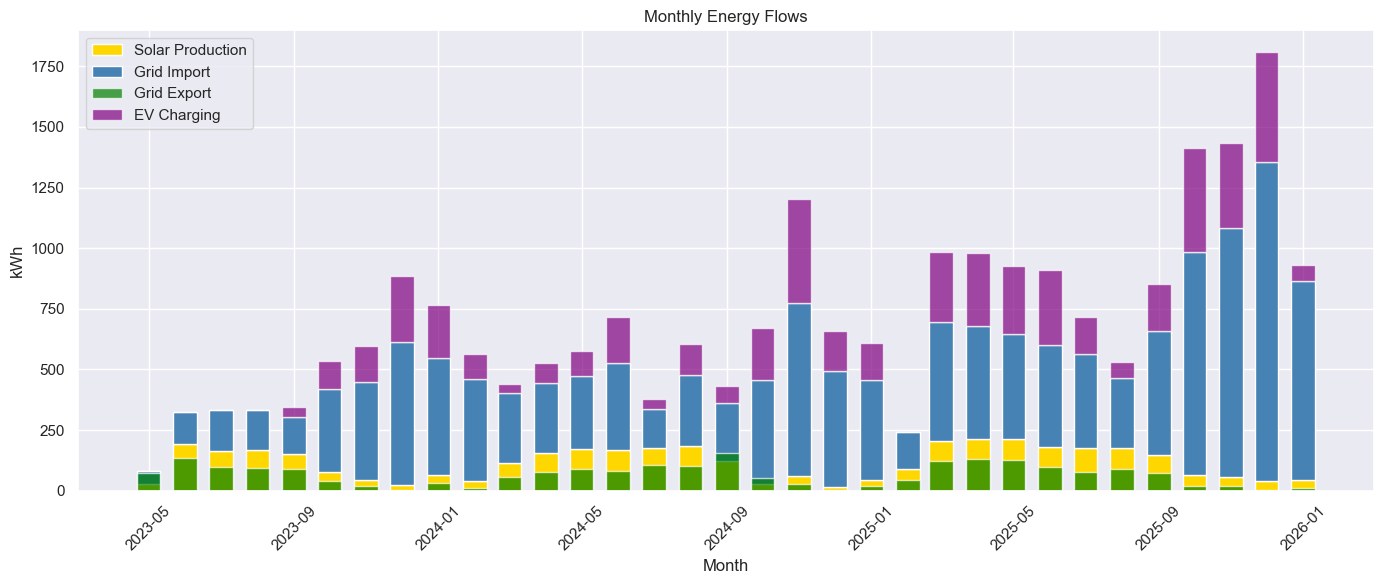

In [79]:
fig, ax = plt.subplots(figsize=(14, 6))

# Energy flows - all as positive values for clarity
ax.bar(df.index, df["Solar Production"], width=20, 
       color="gold", label="Solar Production")
ax.bar(df.index, df["Elec Import"], width=20,
       color="steelblue", label="Grid Import", bottom=df["Solar Production"])
ax.bar(df.index, df["Elec Export"].abs(), width=20,
       color="green", alpha=0.7, label="Grid Export", bottom=0)
ax.bar(df.index, df["EV Charger"].abs(), width=20,
       color="purple", alpha=0.7, label="EV Charging",
       bottom=df["Solar Production"] + df["Elec Import"])

ax.set_title("Monthly Energy Flows")
ax.set_ylabel("kWh")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

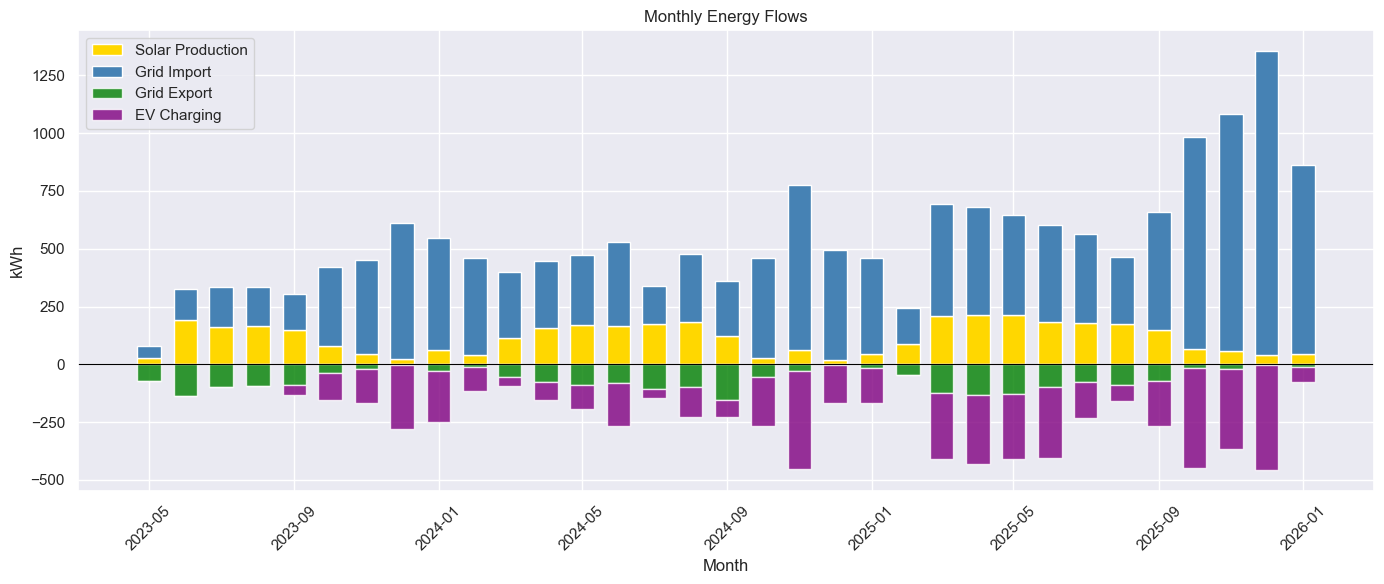

In [80]:
fig, ax = plt.subplots(figsize=(14, 6))

# Energy IN - stacked above zero
ax.bar(df.index, df["Solar Production"], width=20,
       color="gold", label="Solar Production")
ax.bar(df.index, df["Elec Import"], width=20,
       color="steelblue", label="Grid Import",
       bottom=df["Solar Production"])

# Energy OUT - stacked below zero
ax.bar(df.index, -df["Elec Export"].abs(), width=20,
       color="green", alpha=0.8, label="Grid Export")
ax.bar(df.index, -df["EV Charger"].abs(), width=20,
       color="purple", alpha=0.8, label="EV Charging",
       bottom=-df["Elec Export"].abs())

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("Monthly Energy Flows")
ax.set_ylabel("kWh")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [81]:
# Create heating season comparison
# Filter to heating months only (Oct - Apr)
heating_months = df[df.index.month.isin([10, 11, 12, 1, 2, 3, 4])]

# Group by energy year
heating_summary = heating_months.groupby("Energy Year").agg(
    Gas_kWh=("Gas kWh", "sum"),
    Household_Elec=("Household Elec", "sum"),
    Heating_Degree_Days=("Heating Degree Days", "sum")
).reset_index()

print(heating_summary)

  Energy Year   Gas_kWh  Household_Elec  Heating_Degree_Days
0      EY2024  16296.36         2056.25              2019.12
1      EY2025  13853.86         1840.13               864.37
2      EY2026    117.24         2929.31                 0.00


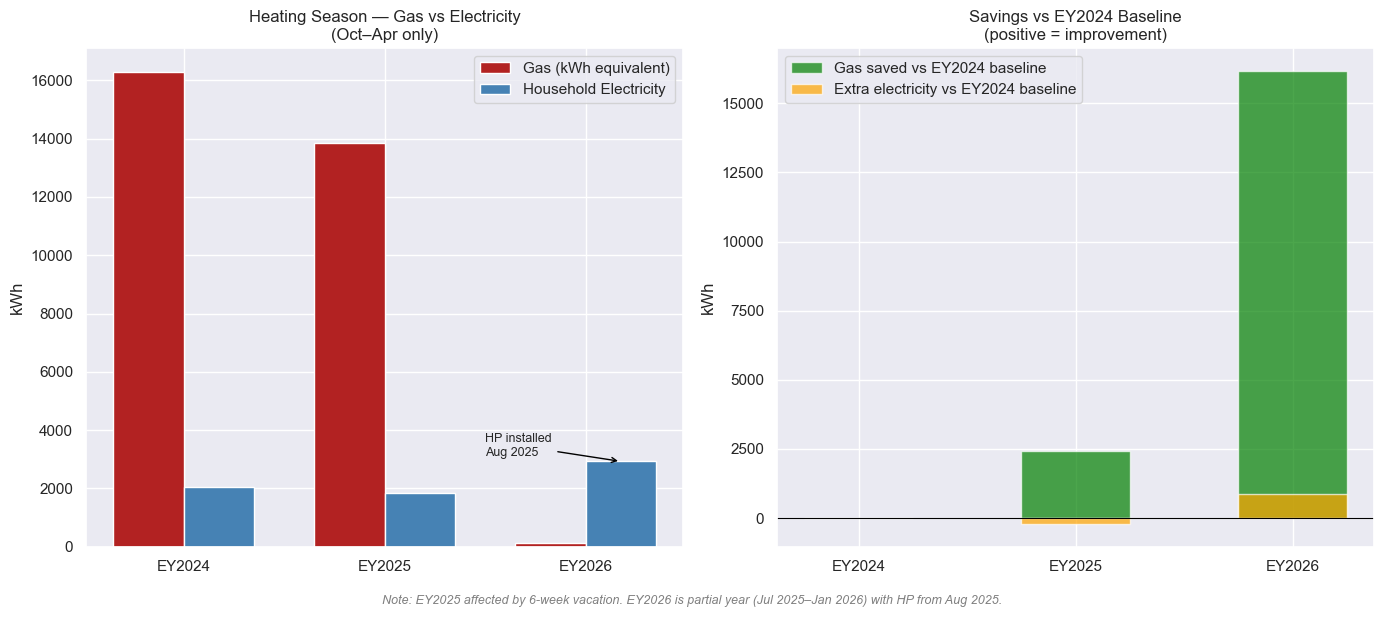

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left - Energy used for heating (gas kWh vs household electricity)
x = np.arange(len(heating_summary))
width = 0.35

ax1.bar(x - width/2, heating_summary["Gas_kWh"], width, 
        color="firebrick", label="Gas (kWh equivalent)")
ax1.bar(x + width/2, heating_summary["Household_Elec"], width,
        color="steelblue", label="Household Electricity")
ax1.set_title("Heating Season — Gas vs Electricity\n(Oct–Apr only)")
ax1.set_ylabel("kWh")
ax1.set_xticks(x)
ax1.set_xticklabels(heating_summary["Energy Year"])
ax1.legend()

# Add annotation for HP installation
ax1.annotate("HP installed\nAug 2025", 
             xy=(2 + width/2, heating_summary["Household_Elec"].iloc[2]),
             xytext=(1.5, heating_summary["Household_Elec"].iloc[2] + 200),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=9)

# Right - Gas savings vs electricity increase
heating_summary["Gas_Saved_kWh"] = heating_summary["Gas_kWh"].iloc[0] - heating_summary["Gas_kWh"]
heating_summary["Elec_Increase_kWh"] = heating_summary["Household_Elec"] - heating_summary["Household_Elec"].iloc[0]

ax2.bar(x, heating_summary["Gas_Saved_kWh"], width=0.5,
        color="green", alpha=0.7, label="Gas saved vs EY2024 baseline")
ax2.bar(x, heating_summary["Elec_Increase_kWh"], width=0.5,
        color="orange", alpha=0.7, label="Extra electricity vs EY2024 baseline")
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_title("Savings vs EY2024 Baseline\n(positive = improvement)")
ax2.set_ylabel("kWh")
ax2.set_xticks(x)
ax2.set_xticklabels(heating_summary["Energy Year"])
ax2.legend()

# Add caveat note
fig.text(0.5, -0.02, 
         "Note: EY2025 affected by 6-week vacation. EY2026 is partial year (Jul 2025–Jan 2026) with HP from Aug 2025.",
         ha="center", fontsize=9, style="italic", color="grey")

plt.tight_layout()
plt.show()

In [83]:
# Recalculate as deltas vs EY2024 baseline
heating_summary["Gas_Delta"] = heating_summary["Gas_kWh"] - heating_summary["Gas_kWh"].iloc[0]
heating_summary["Elec_Delta"] = heating_summary["Household_Elec"] - heating_summary["Household_Elec"].iloc[0]

print(heating_summary[["Energy Year", "Gas_Delta", "Elec_Delta"]])

  Energy Year  Gas_Delta  Elec_Delta
0      EY2024       0.00        0.00
1      EY2025   -2442.50     -216.12
2      EY2026  -16179.12      873.06


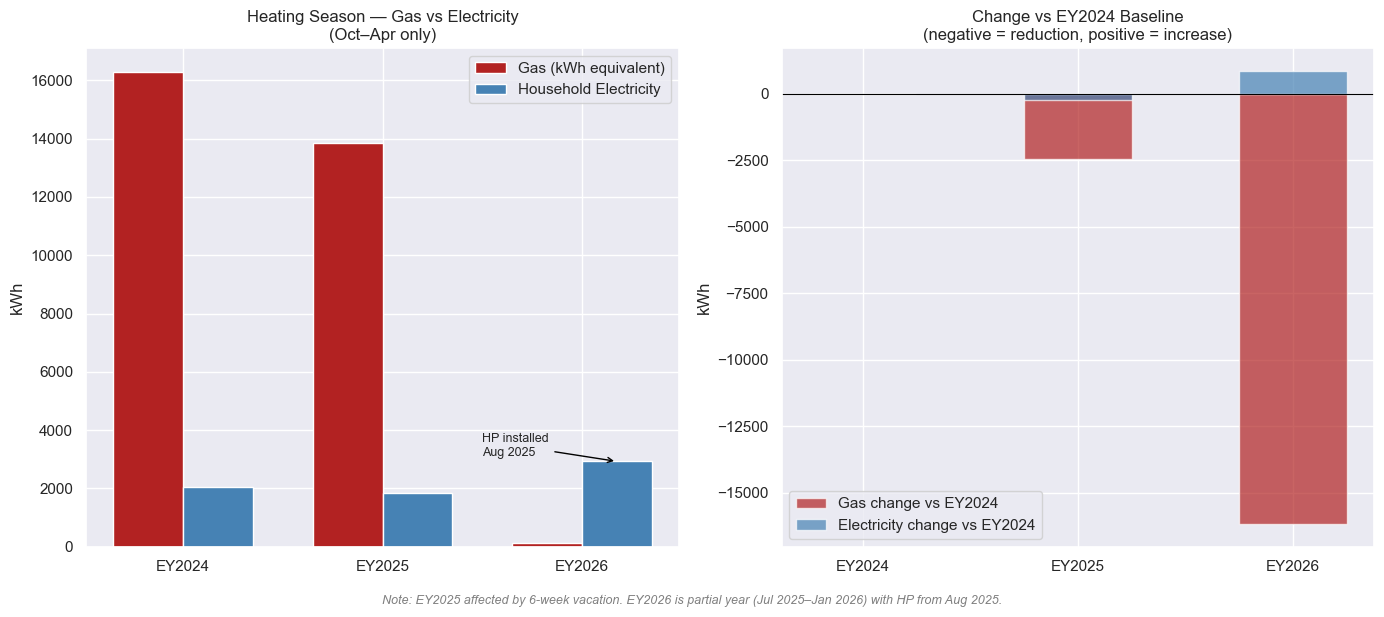

In [84]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left chart - unchanged
x = np.arange(len(heating_summary))
width = 0.35

ax1.bar(x - width/2, heating_summary["Gas_kWh"], width,
        color="firebrick", label="Gas (kWh equivalent)")
ax1.bar(x + width/2, heating_summary["Household_Elec"], width,
        color="steelblue", label="Household Electricity")
ax1.set_title("Heating Season — Gas vs Electricity\n(Oct–Apr only)")
ax1.set_ylabel("kWh")
ax1.set_xticks(x)
ax1.set_xticklabels(heating_summary["Energy Year"])
ax1.legend()
ax1.annotate("HP installed\nAug 2025",
             xy=(2 + width/2, heating_summary["Household_Elec"].iloc[2]),
             xytext=(1.5, heating_summary["Household_Elec"].iloc[2] + 200),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=9)

# Right chart - delta vs EY2024 baseline
ax2.bar(x, heating_summary["Gas_Delta"], width=0.5,
        color="firebrick", alpha=0.7, label="Gas change vs EY2024")
ax2.bar(x, heating_summary["Elec_Delta"], width=0.5,
        color="steelblue", alpha=0.7, label="Electricity change vs EY2024")
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_title("Change vs EY2024 Baseline\n(negative = reduction, positive = increase)")
ax2.set_ylabel("kWh")
ax2.set_xticks(x)
ax2.set_xticklabels(heating_summary["Energy Year"])
ax2.legend()

fig.text(0.5, -0.02,
         "Note: EY2025 affected by 6-week vacation. EY2026 is partial year (Jul 2025–Jan 2026) with HP from Aug 2025.",
         ha="center", fontsize=9, style="italic", color="grey")

plt.tight_layout()
plt.show()

In [85]:
# Filter to Oct-Jan only for fair comparison
heating_months_fair = df[df.index.month.isin([10, 11, 12, 1])]

heating_summary_fair = heating_months_fair.groupby("Energy Year").agg(
    Gas_kWh=("Gas kWh", "sum"),
    Household_Elec=("Household Elec", "sum"),
    Heating_Degree_Days=("Heating Degree Days", "sum")
).reset_index()

# Calculate COP for each energy year vs EY2024 baseline
heating_summary_fair["Gas_Delta"] = heating_summary_fair["Gas_kWh"] - heating_summary_fair["Gas_kWh"].iloc[0]
heating_summary_fair["Elec_Delta"] = heating_summary_fair["Household_Elec"] - heating_summary_fair["Household_Elec"].iloc[0]

# COP only meaningful for EY2026 where HP was running
ey2026 = heating_summary_fair[heating_summary_fair["Energy Year"] == "EY2026"].iloc[0]
cop_estimate = abs(ey2026["Gas_Delta"]) / ey2026["Elec_Delta"]

print(heating_summary_fair[["Energy Year", "Gas_kWh", "Household_Elec", 
                              "Gas_Delta", "Elec_Delta"]])
print(f"\nEstimated COP (Oct-Jan, vs EY2024 baseline): {cop_estimate:.2f}")
print(f"Note: EY2025 baseline distorted by 6-week vacation")

  Energy Year   Gas_kWh  Household_Elec  Gas_Delta  Elec_Delta
0      EY2024  10698.15         1122.74       0.00        0.00
1      EY2025   9701.61         1112.11    -996.54      -10.63
2      EY2026    117.24         2929.31  -10580.91     1806.57

Estimated COP (Oct-Jan, vs EY2024 baseline): 5.86
Note: EY2025 baseline distorted by 6-week vacation


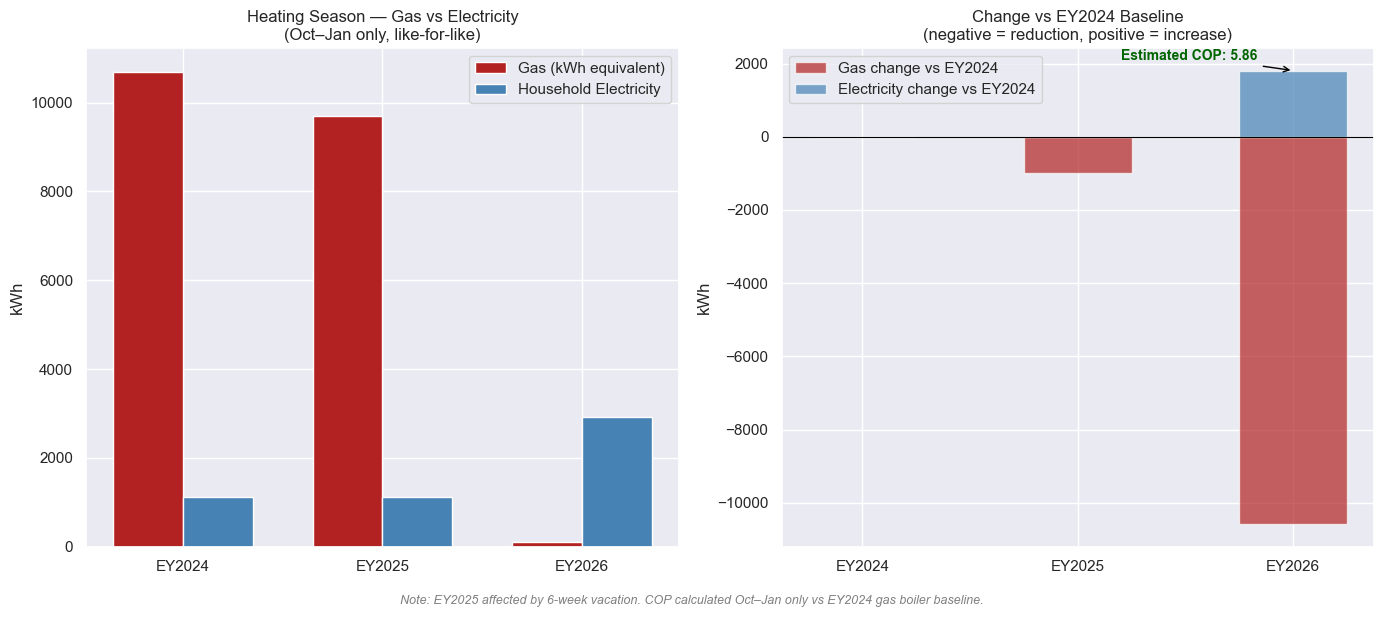

In [87]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

x = np.arange(len(heating_summary_fair))
width = 0.35

# Left - Gas vs Electricity (Oct-Jan only)
ax1.bar(x - width/2, heating_summary_fair["Gas_kWh"], width,
        color="firebrick", label="Gas (kWh equivalent)")
ax1.bar(x + width/2, heating_summary_fair["Household_Elec"], width,
        color="steelblue", label="Household Electricity")
ax1.set_title("Heating Season — Gas vs Electricity\n(Oct–Jan only, like-for-like)")
ax1.set_ylabel("kWh")
ax1.set_xticks(x)
ax1.set_xticklabels(heating_summary_fair["Energy Year"])
ax1.legend()

# Right - Delta vs EY2024 baseline
ax2.bar(x, heating_summary_fair["Gas_Delta"], width=0.5,
        color="firebrick", alpha=0.7, label="Gas change vs EY2024")
ax2.bar(x, heating_summary_fair["Elec_Delta"], width=0.5,
        color="steelblue", alpha=0.7, label="Electricity change vs EY2024")
ax2.axhline(y=0, color="black", linewidth=0.8)

# Add COP annotation
ax2.annotate(f"Estimated COP: {cop_estimate:.2f}",
             xy=(2, ey2026["Elec_Delta"]),
             xytext=(1.2, ey2026["Elec_Delta"] + 300),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=10, color="darkgreen", fontweight="bold")

ax2.set_title("Change vs EY2024 Baseline\n(negative = reduction, positive = increase)")
ax2.set_ylabel("kWh")
ax2.set_xticks(x)
ax2.set_xticklabels(heating_summary_fair["Energy Year"])
ax2.legend()

fig.text(0.5, -0.02,
         "Note: EY2025 affected by 6-week vacation. COP calculated Oct–Jan only vs EY2024 gas boiler baseline.",
         ha="center", fontsize=9, style="italic", color="grey")

plt.tight_layout()
plt.show()

In [88]:
print(df[["Gas Cost", "Elec Import Cost", "Feedback Costs", 
          "Fixed Costs", "Export Income", "EV Charger.1"]].head(10).to_string())

            Gas Cost  Elec Import Cost  Feedback Costs  Fixed Costs  Export Income  EV Charger.1
Date                                                                                            
2023-05-01      9.57             21.46             0.0         4.79         -28.58          0.00
2023-06-01     35.53             51.38             0.0         9.59         -53.64          0.00
2023-07-01     49.19             66.87             0.0         9.91         -38.27          0.00
2023-08-01     39.63             65.08             0.0         9.91         -36.82          0.00
2023-09-01     24.60             61.08             0.0         9.59         -35.81        -10.03
2023-10-01    172.18            133.36             0.0         9.91         -15.31        -39.26
2023-11-01    349.82            156.94             0.0         9.59          -7.92        -52.24
2023-12-01    434.55            228.40             0.0         9.91          -1.96       -103.12
2024-01-01    584.32          

In [89]:
# Flip signs for cost/income columns
# Costs should be negative, income should be positive
df["Gas Cost"] = df["Gas Cost"] * -1
df["Elec Import Cost"] = df["Elec Import Cost"] * -1
df["Feedback Costs"] = df["Feedback Costs"] * -1
df["Fixed Costs"] = df["Fixed Costs"] * -1
df["Export Income"] = df["Export Income"] * -1
df["EV Charger.1"] = df["EV Charger.1"] * -1

# Verify
print(df[["Gas Cost", "Elec Import Cost", "Feedback Costs",
          "Fixed Costs", "Export Income", "EV Charger.1"]].head(10).to_string())

            Gas Cost  Elec Import Cost  Feedback Costs  Fixed Costs  Export Income  EV Charger.1
Date                                                                                            
2023-05-01     -9.57            -21.46            -0.0        -4.79          28.58         -0.00
2023-06-01    -35.53            -51.38            -0.0        -9.59          53.64         -0.00
2023-07-01    -49.19            -66.87            -0.0        -9.91          38.27         -0.00
2023-08-01    -39.63            -65.08            -0.0        -9.91          36.82         -0.00
2023-09-01    -24.60            -61.08            -0.0        -9.59          35.81         10.03
2023-10-01   -172.18           -133.36            -0.0        -9.91          15.31         39.26
2023-11-01   -349.82           -156.94            -0.0        -9.59           7.92         52.24
2023-12-01   -434.55           -228.40            -0.0        -9.91           1.96        103.12
2024-01-01   -584.32          

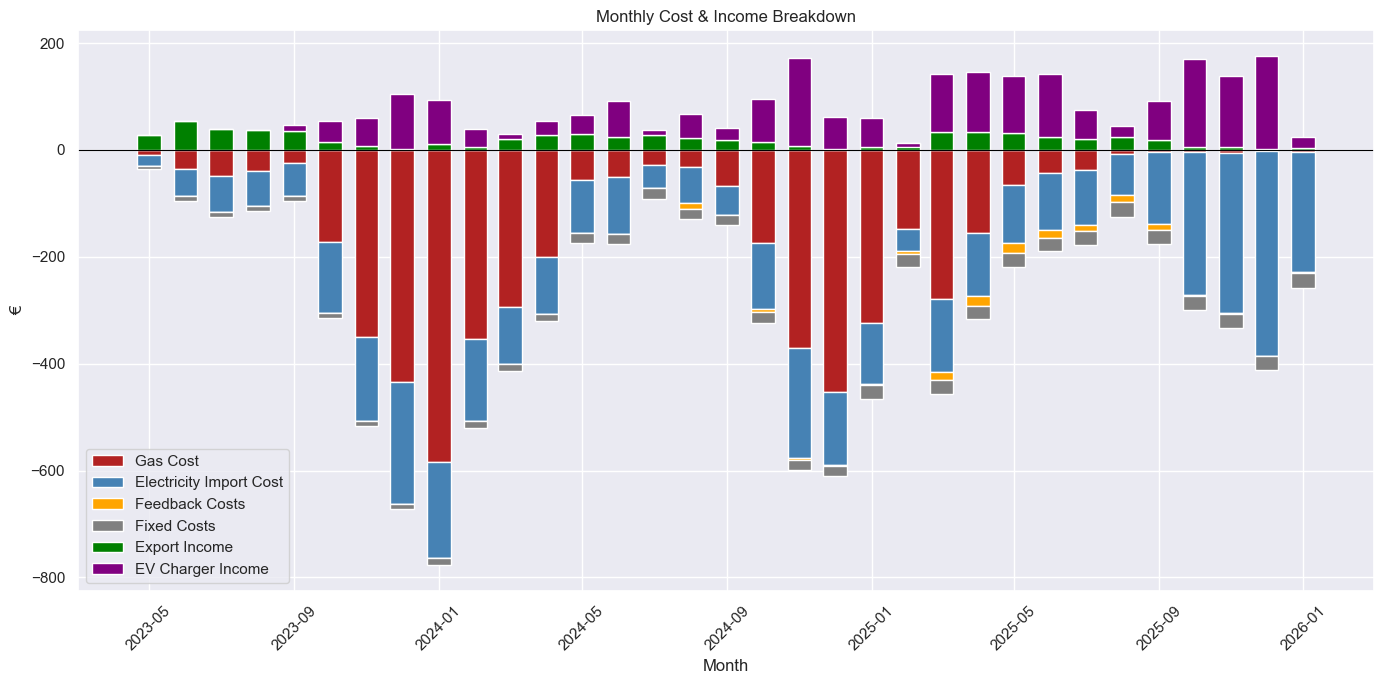

In [90]:
fig, ax = plt.subplots(figsize=(14, 7))

# Costs (negative bars, below zero)
ax.bar(df.index, df["Gas Cost"], width=20,
       color="firebrick", label="Gas Cost")
ax.bar(df.index, df["Elec Import Cost"], width=20,
       color="steelblue", label="Electricity Import Cost",
       bottom=df["Gas Cost"])
ax.bar(df.index, df["Feedback Costs"], width=20,
       color="orange", label="Feedback Costs",
       bottom=df["Gas Cost"] + df["Elec Import Cost"])
ax.bar(df.index, df["Fixed Costs"], width=20,
       color="grey", label="Fixed Costs",
       bottom=df["Gas Cost"] + df["Elec Import Cost"] + df["Feedback Costs"])

# Income (positive bars, above zero)
ax.bar(df.index, df["Export Income"], width=20,
       color="green", label="Export Income")
ax.bar(df.index, df["EV Charger.1"], width=20,
       color="purple", label="EV Charger Income",
       bottom=df["Export Income"])

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("Monthly Cost & Income Breakdown")
ax.set_ylabel("€")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

In [91]:
# Calculate net position per month
df["Net Position"] = (df["Export Income"] + df["EV Charger.1"] + 
                      df["Gas Cost"] + df["Elec Import Cost"] + 
                      df["Feedback Costs"] + df["Fixed Costs"])

print(df[["Net Position"]].to_string())

            Net Position
Date                    
2023-05-01         -7.24
2023-06-01        -42.86
2023-07-01        -87.70
2023-08-01        -77.80
2023-09-01        -49.43
2023-10-01       -260.88
2023-11-01       -456.19
2023-12-01       -567.78
2024-01-01       -684.58
2024-02-01       -481.16
2024-03-01       -384.13
2024-04-01       -266.47
2024-05-01       -107.73
2024-06-01        -84.40
2024-07-01        -53.43
2024-08-01        -62.84
2024-09-01        -99.25
2024-10-01       -228.46
2024-11-01       -426.44
2024-12-01       -549.78
2025-01-01       -408.10
2025-02-01       -212.63
2025-03-01       -313.76
2025-04-01       -171.14
2025-05-01        -81.16
2025-06-01        -48.06
2025-07-01       -102.84
2025-08-01        -80.22
2025-09-01        -85.12
2025-10-01       -130.01
2025-11-01       -194.65
2025-12-01       -236.65
2026-01-01       -235.64


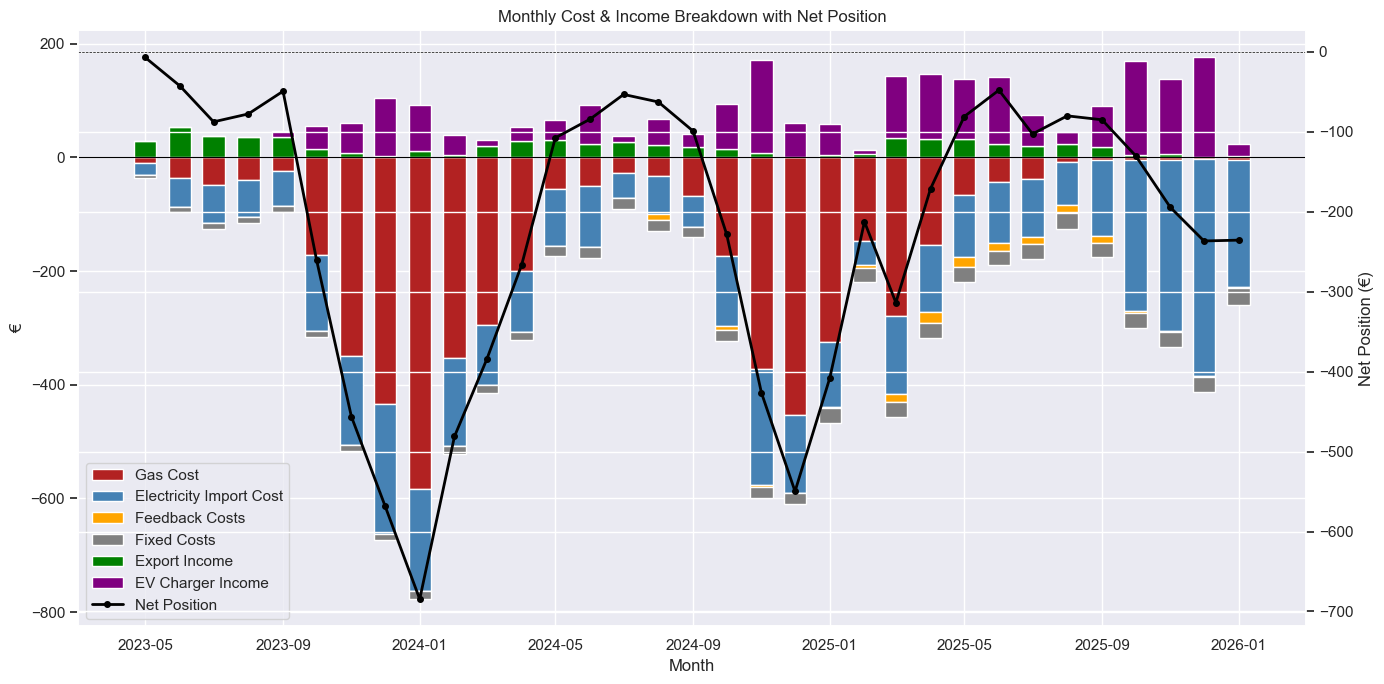

In [92]:
fig, ax = plt.subplots(figsize=(14, 7))

# Costs (negative bars, below zero)
ax.bar(df.index, df["Gas Cost"], width=20,
       color="firebrick", label="Gas Cost")
ax.bar(df.index, df["Elec Import Cost"], width=20,
       color="steelblue", label="Electricity Import Cost",
       bottom=df["Gas Cost"])
ax.bar(df.index, df["Feedback Costs"], width=20,
       color="orange", label="Feedback Costs",
       bottom=df["Gas Cost"] + df["Elec Import Cost"])
ax.bar(df.index, df["Fixed Costs"], width=20,
       color="grey", label="Fixed Costs",
       bottom=df["Gas Cost"] + df["Elec Import Cost"] + df["Feedback Costs"])

# Income (positive bars, above zero)
ax.bar(df.index, df["Export Income"], width=20,
       color="green", label="Export Income")
ax.bar(df.index, df["EV Charger.1"], width=20,
       color="purple", label="EV Charger Income",
       bottom=df["Export Income"])

# Net position line
ax2 = ax.twinx()
ax2.plot(df.index, df["Net Position"], 
         color="black", linewidth=2, marker="o", markersize=4,
         label="Net Position")
ax2.axhline(y=0, color="black", linewidth=0.5, linestyle="--")
ax2.set_ylabel("Net Position (€)")

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("Monthly Cost & Income Breakdown with Net Position")
ax.set_ylabel("€")
ax.set_xlabel("Month")
plt.xticks(rotation=45)

# Combine legends from both axes
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="lower left")

plt.tight_layout()
plt.show()

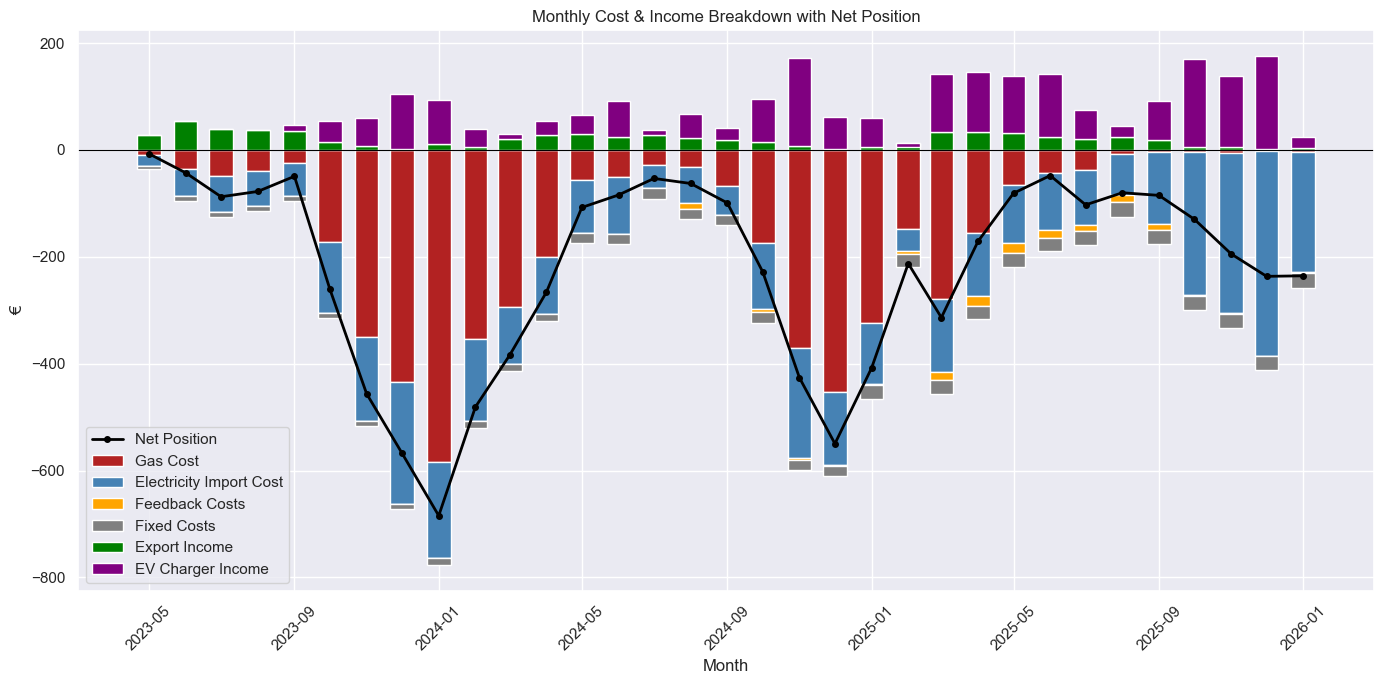

In [93]:
fig, ax = plt.subplots(figsize=(14, 7))

# Costs (negative bars, below zero)
ax.bar(df.index, df["Gas Cost"], width=20,
       color="firebrick", label="Gas Cost")
ax.bar(df.index, df["Elec Import Cost"], width=20,
       color="steelblue", label="Electricity Import Cost",
       bottom=df["Gas Cost"])
ax.bar(df.index, df["Feedback Costs"], width=20,
       color="orange", label="Feedback Costs",
       bottom=df["Gas Cost"] + df["Elec Import Cost"])
ax.bar(df.index, df["Fixed Costs"], width=20,
       color="grey", label="Fixed Costs",
       bottom=df["Gas Cost"] + df["Elec Import Cost"] + df["Feedback Costs"])

# Income (positive bars, above zero)
ax.bar(df.index, df["Export Income"], width=20,
       color="green", label="Export Income")
ax.bar(df.index, df["EV Charger.1"], width=20,
       color="purple", label="EV Charger Income",
       bottom=df["Export Income"])

# Net position line on same axis
ax.plot(df.index, df["Net Position"],
        color="black", linewidth=2, marker="o", markersize=4,
        label="Net Position")

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("Monthly Cost & Income Breakdown with Net Position")
ax.set_ylabel("€")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

In [95]:
# Calculate EV electricity cost
# Assumes 100% grid charging at average electricity tariff
df["EV Electricity Cost"] = df["EV Charger"].abs() * df["Elec Tariff"]

# Verify
print(df[["EV Charger", "Elec Tariff", "EV Electricity Cost"]].head(10).to_string())

            EV Charger Elec Tariff EV Electricity Cost
Date                                                  
2023-05-01        0.00    0.390182                 0.0
2023-06-01        0.00    0.389242                 0.0
2023-07-01        0.00    0.388779                 0.0
2023-08-01        0.00    0.389701                 0.0
2023-09-01      -40.26    0.391538           15.763338
2023-10-01     -113.49    0.387674            43.99717
2023-11-01     -145.99    0.388465           56.712056
2023-12-01     -273.35    0.387119          105.818881
2024-01-01     -218.43    0.368082           80.400255
2024-02-01     -103.03    0.367637           37.877664


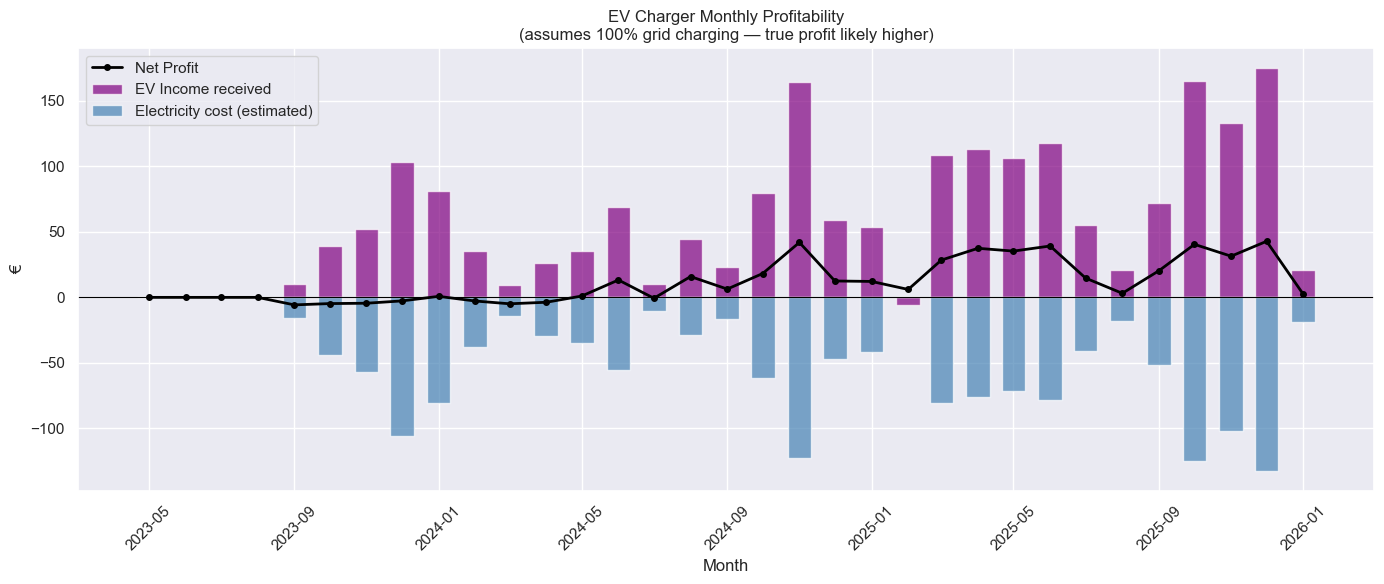

In [96]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(df.index, df["EV Charger.1"], width=20,
       color="purple", alpha=0.7, label="EV Income received")
ax.bar(df.index, df["EV Electricity Cost"] * -1, width=20,
       color="steelblue", alpha=0.7, label="Electricity cost (estimated)")
ax.plot(df.index, df["EV Net Profit"],
        color="black", linewidth=2, marker="o", markersize=4,
        label="Net Profit")

ax.axhline(y=0, color="black", linewidth=0.8)
ax.set_title("EV Charger Monthly Profitability\n(assumes 100% grid charging — true profit likely higher)")
ax.set_ylabel("€")
ax.set_xlabel("Month")
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

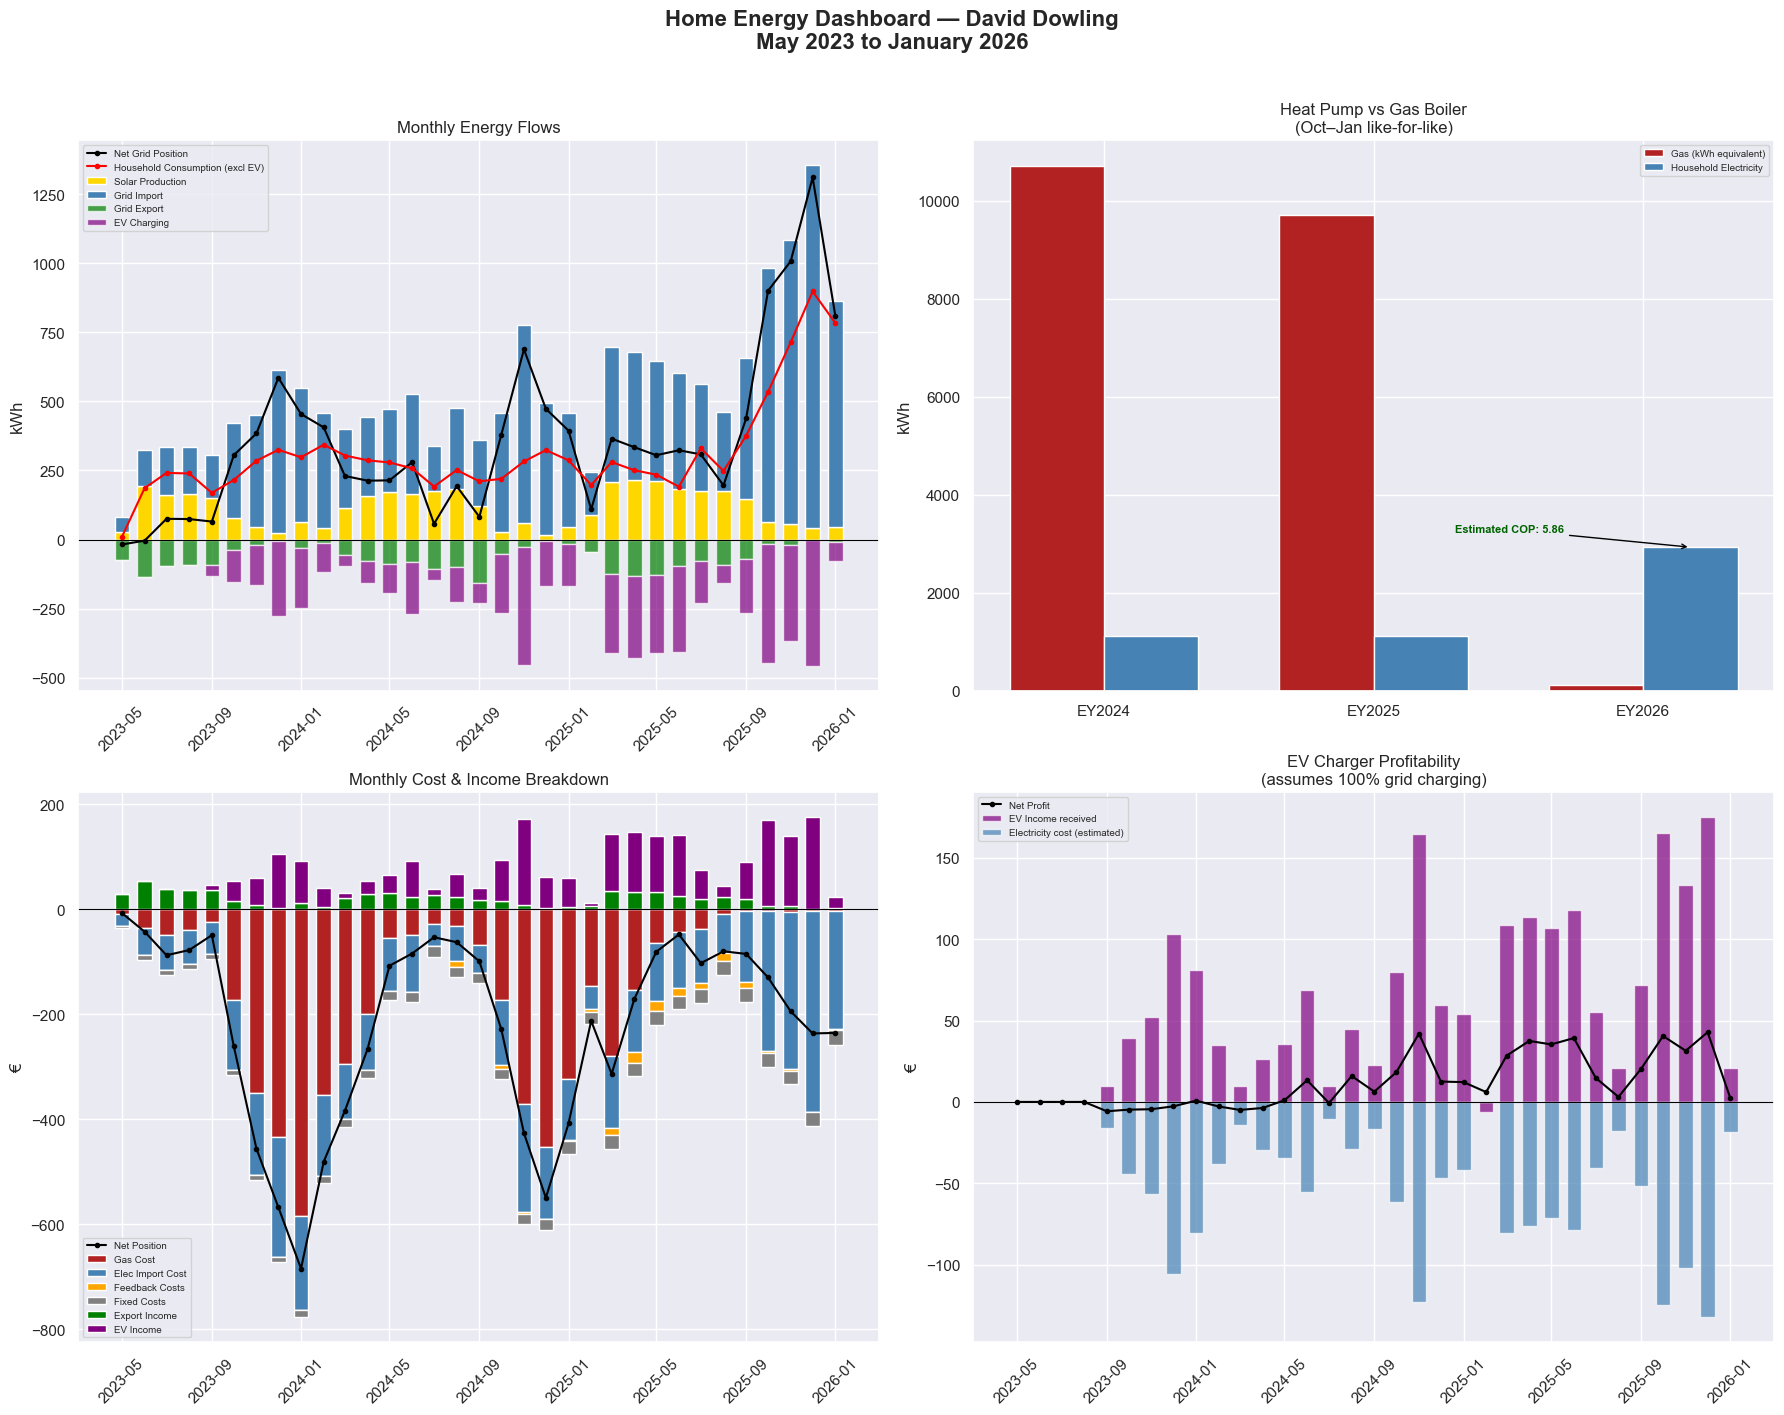

Dashboard saved as home_energy_dashboard.png ✓


In [99]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Home Energy Dashboard — David Dowling\nMay 2023 to January 2026", 
             fontsize=16, fontweight="bold", y=1.01)

# ── CHART 1: Monthly Energy Flows (top left) ──────────
ax1 = fig.add_subplot(2, 2, 1)
ax1.bar(df.index, df["Solar Production"], width=20,
        color="gold", label="Solar Production")
ax1.bar(df.index, df["Elec Import"], width=20,
        color="steelblue", label="Grid Import",
        bottom=df["Solar Production"])
ax1.bar(df.index, df["Elec Export"].abs() * -1, width=20,
        color="green", alpha=0.7, label="Grid Export")
ax1.bar(df.index, df["EV Charger"].abs() * -1, width=20,
        color="purple", alpha=0.7, label="EV Charging",
        bottom=df["Elec Export"])
ax1.axhline(y=0, color="black", linewidth=0.8)
ax1.plot(df.index, df["Net Grid Use"],
         color="black", linewidth=1.5, marker="o", markersize=3,
         label="Net Grid Position")
ax1.plot(df.index, df["Household Elec"],
         color="red", linewidth=1.5, marker="o", markersize=3,
         label="Household Consumption (excl EV)")
ax1.set_title("Monthly Energy Flows")
ax1.set_ylabel("kWh")
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)
ax1.legend(fontsize=7)

# ── CHART 2: Heat Pump vs Gas Boiler (top right) ──────
ax2 = fig.add_subplot(2, 2, 2)
x = np.arange(len(heating_summary_fair))
width = 0.35
ax2.bar(x - width/2, heating_summary_fair["Gas_kWh"], width,
        color="firebrick", label="Gas (kWh equivalent)")
ax2.bar(x + width/2, heating_summary_fair["Household_Elec"], width,
        color="steelblue", label="Household Electricity")
ax2.set_title("Heat Pump vs Gas Boiler\n(Oct–Jan like-for-like)")
ax2.set_ylabel("kWh")
ax2.set_xticks(x)
ax2.set_xticklabels(heating_summary_fair["Energy Year"])
ax2.legend(fontsize=7)
ax2.annotate(f"Estimated COP: {cop_estimate:.2f}",
             xy=(2 + width/2, heating_summary_fair["Household_Elec"].iloc[2]),
             xytext=(1.3, heating_summary_fair["Household_Elec"].iloc[2] + 300),
             arrowprops=dict(arrowstyle="->", color="black"),
             fontsize=8, color="darkgreen", fontweight="bold")

# ── CHART 3: Monthly Cost Breakdown (bottom left) ─────
ax3 = fig.add_subplot(2, 2, 3)
ax3.bar(df.index, df["Gas Cost"], width=20,
        color="firebrick", label="Gas Cost")
ax3.bar(df.index, df["Elec Import Cost"], width=20,
        color="steelblue", label="Elec Import Cost",
        bottom=df["Gas Cost"])
ax3.bar(df.index, df["Feedback Costs"], width=20,
        color="orange", label="Feedback Costs",
        bottom=df["Gas Cost"] + df["Elec Import Cost"])
ax3.bar(df.index, df["Fixed Costs"], width=20,
        color="grey", label="Fixed Costs",
        bottom=df["Gas Cost"] + df["Elec Import Cost"] + df["Feedback Costs"])
ax3.bar(df.index, df["Export Income"], width=20,
        color="green", label="Export Income")
ax3.bar(df.index, df["EV Charger.1"], width=20,
        color="purple", label="EV Income",
        bottom=df["Export Income"])
ax3.plot(df.index, df["Net Position"],
         color="black", linewidth=1.5, marker="o", markersize=3,
         label="Net Position")
ax3.axhline(y=0, color="black", linewidth=0.8)
ax3.set_title("Monthly Cost & Income Breakdown")
ax3.set_ylabel("€")
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)
ax3.legend(fontsize=7, loc="lower left")

# ── CHART 4: EV Profitability (bottom right) ──────────
ax4 = fig.add_subplot(2, 2, 4)
ax4.bar(df.index, df["EV Charger.1"], width=20,
        color="purple", alpha=0.7, label="EV Income received")
ax4.bar(df.index, df["EV Electricity Cost"] * -1, width=20,
        color="steelblue", alpha=0.7, label="Electricity cost (estimated)")
ax4.plot(df.index, df["EV Net Profit"],
         color="black", linewidth=1.5, marker="o", markersize=3,
         label="Net Profit")
ax4.axhline(y=0, color="black", linewidth=0.8)
ax4.set_title("EV Charger Profitability\n(assumes 100% grid charging)")
ax4.set_ylabel("€")
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)
ax4.legend(fontsize=7)

plt.tight_layout()
plt.savefig("home_energy_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Dashboard saved as home_energy_dashboard.png ✓")